# Test III: VQC (Tuned) — PCA + Variational Quantum Classifier

Tuned hyperparameters vs v1:
- **Batch size:** 16 → 64 (lower gradient variance)
- **SPSA epsilon:** 0.1 → 0.02 (more precise gradient)
- **LR:** 0.05 → 0.1 (compensate for smaller epsilon)
- **Epochs:** 30 → 50
- **Train subset:** 3000 → 6000
- **Multiple SPSA samples:** average 3 SPSA perturbations per step

In [1]:
import os, time, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import cudaq
from cudaq import spin
import warnings; warnings.filterwarnings('ignore')

try: cudaq.set_target('nvidia'); print('GPU target')
except: print('CPU target')

GPU target


In [2]:
# === Config ===
N_QUBITS = 16; N_LAYERS = 3; N_CLASSES = 3
N_PARAMS = N_LAYERS * 2 * N_QUBITS  # 96
BATCH_SIZE = 64; NUM_EPOCHS = 50; LR = 0.1; MOMENTUM = 0.9
EPSILON = 0.02; N_SPSA_AVG = 3; TRAIN_SUBSET = 6000
CLASS_NAMES = ['no', 'sphere', 'vort']; DATA_DIR = 'data'
print(f'VQC: {N_QUBITS}q, {N_LAYERS}L, {N_PARAMS} params, bs={BATCH_SIZE}, eps={EPSILON}')

VQC: 16q, 3L, 96 params, bs=64, eps=0.02


In [3]:
# Load + PCA
def load_split(split):
    images, labels = [], []
    for ci, cn in enumerate(CLASS_NAMES):
        d = os.path.join(DATA_DIR, split, cn)
        for f in sorted(os.listdir(d)):
            if f.endswith('.npy'):
                images.append(np.load(os.path.join(d,f)).astype(np.float32).flatten())
                labels.append(ci)
    return np.array(images), np.array(labels)

X_train_raw, y_train = load_split('train')
X_val_raw, y_val = load_split('val')

pca = PCA(n_components=N_QUBITS)
X_train_pca = pca.fit_transform(X_train_raw)
X_val_pca = pca.transform(X_val_raw)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}')

pca_min, pca_max = X_train_pca.min(0), X_train_pca.max(0)
X_train_norm = (X_train_pca - pca_min) / (pca_max - pca_min + 1e-8)
X_val_norm = np.clip((X_val_pca - pca_min) / (pca_max - pca_min + 1e-8), 0, 1)

# Subsample
idx = []
for c in range(3):
    ci = np.where(y_train == c)[0]
    idx.extend(np.random.choice(ci, TRAIN_SUBSET//3, replace=False).tolist())
np.random.shuffle(idx)
X_tr = torch.tensor(X_train_norm[idx], dtype=torch.float32)
y_tr = torch.tensor(y_train[idx], dtype=torch.long)
X_vl = torch.tensor(X_val_norm, dtype=torch.float32)
y_vl = torch.tensor(y_val, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
print(f'Train: {len(X_tr)}, Val: {len(X_vl)}, Steps/epoch: {len(train_loader)}')

PCA explained variance: 0.8523
Train: 6000, Val: 7500, Steps/epoch: 94


In [4]:
# Quantum circuit
@cudaq.kernel
def vqc_kernel(data: list[float], params: list[float],
               n_qubits: int, n_layers: int):
    q = cudaq.qvector(n_qubits)
    for layer in range(n_layers):
        base = layer * 2 * n_qubits
        for i in range(n_qubits):
            ry(data[i] * 3.14159265 + params[base + i], q[i])
        for i in range(n_qubits - 1):
            x.ctrl(q[i], q[i + 1])
        x.ctrl(q[n_qubits - 1], q[0])
        for i in range(n_qubits):
            rz(params[base + n_qubits + i], q[i])

CLASS_OBS = [spin.z(i) for i in range(N_CLASSES)]
COMBINED_OBS = sum(CLASS_OBS)

def run_vqc(data_list, params_list):
    r = cudaq.observe(vqc_kernel, COMBINED_OBS, data_list, params_list, N_QUBITS, N_LAYERS)
    return [r.expectation(o) for o in CLASS_OBS]

def forward_batch(X, params_list):
    B = X.shape[0]
    logits = np.zeros((B, N_CLASSES))
    for b in range(B):
        e = run_vqc(X[b].tolist(), params_list)
        for c in range(N_CLASSES): logits[b,c] = e[c]
    return logits

def cross_entropy(logits, labels):
    e = np.exp(logits - logits.max(1, keepdims=True))
    p = e / e.sum(1, keepdims=True)
    return -np.mean(np.log(p[np.arange(len(labels)), labels] + 1e-10))

print('Circuit ready')

Circuit ready


In [5]:
def spsa_gradient_avg(X_batch, y_batch, params_np, epsilon, n_avg):
    """Average multiple SPSA gradient estimates for lower variance."""
    X_np, y_np = X_batch.numpy(), y_batch.numpy()
    grad_sum = np.zeros_like(params_np)
    loss_sum = 0.0
    for _ in range(n_avg):
        delta = np.random.choice([-1.0, 1.0], size=params_np.shape)
        l_plus = cross_entropy(forward_batch(X_np, (params_np + epsilon*delta).tolist()), y_np)
        l_minus = cross_entropy(forward_batch(X_np, (params_np - epsilon*delta).tolist()), y_np)
        grad_sum += (l_plus - l_minus) / (2.0 * epsilon) / delta
        loss_sum += (l_plus + l_minus) / 2.0
    return grad_sum / n_avg, loss_sum / n_avg

def evaluate(params_np, X, y, bs=256):
    params_list = params_np.tolist()
    all_probs, all_labels = [], []
    for i in range(0, len(X), bs):
        logits = forward_batch(X[i:i+bs].numpy(), params_list)
        e = np.exp(logits - logits.max(1, keepdims=True))
        all_probs.append(e / e.sum(1, keepdims=True))
        all_labels.append(y[i:i+bs].numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    acc = (probs.argmax(1) == labels).mean()
    return acc, probs, labels

# Benchmark
t0 = time.time()
_, _ = spsa_gradient_avg(X_tr[:BATCH_SIZE], y_tr[:BATCH_SIZE], np.random.randn(N_PARAMS)*0.1, EPSILON, N_SPSA_AVG)
step_time = time.time() - t0
print(f'SPSA step (bs={BATCH_SIZE}, avg={N_SPSA_AVG}): {step_time:.2f}s')
print(f'Estimated: {len(train_loader)*step_time/60:.1f} min/epoch')

SPSA step (bs=64, avg=3): 3.30s
Estimated: 5.2 min/epoch


In [6]:
# Training
params = np.random.randn(N_PARAMS) * 0.1
velocity = np.zeros_like(params)
best_val_acc, best_params = 0.0, params.copy()
history = {'train_loss': [], 'val_acc': []}

ckpt_path = 'vqc_tuned_ckpt.npz'
start_epoch = 0
if os.path.exists(ckpt_path):
    ck = np.load(ckpt_path, allow_pickle=True)
    params, velocity = ck['params'], ck['velocity']
    best_params, best_val_acc = ck['best_params'], float(ck['best_val_acc'])
    start_epoch = int(ck['epoch'])
    history = ck['history'].item()
    print(f'Resumed from epoch {start_epoch}')

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()
    eloss, ns = 0., 0
    for Xb, yb in train_loader:
        grad, loss = spsa_gradient_avg(Xb, yb, params, EPSILON, N_SPSA_AVG)
        velocity = MOMENTUM * velocity - LR * grad
        params = params + velocity
        eloss += loss; ns += 1
    
    val_acc, _, _ = evaluate(params, X_vl[:1500], y_vl[:1500])
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_params = params.copy()
    history['train_loss'].append(eloss/ns)
    history['val_acc'].append(val_acc)
    np.savez(ckpt_path, params=params, velocity=velocity,
             best_params=best_params, best_val_acc=best_val_acc,
             epoch=epoch+1, history=history)
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} ({time.time()-t0:.0f}s) | '
          f'Loss: {eloss/ns:.4f} | Val Acc: {val_acc:.4f} | Best: {best_val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Resumed from epoch 44


Epoch 45/50 (248s) | Loss: 1.0982 | Val Acc: 0.1160 | Best: 0.2920


Epoch 46/50 (247s) | Loss: 1.0980 | Val Acc: 0.4060 | Best: 0.4060


Epoch 47/50 (247s) | Loss: 1.0978 | Val Acc: 0.4787 | Best: 0.4787


Epoch 48/50 (246s) | Loss: 1.0980 | Val Acc: 0.4367 | Best: 0.4787


Epoch 49/50 (247s) | Loss: 1.0978 | Val Acc: 0.4607 | Best: 0.4787


Epoch 50/50 (247s) | Loss: 1.0976 | Val Acc: 0.4760 | Best: 0.4787

Best Val Accuracy: 0.4787


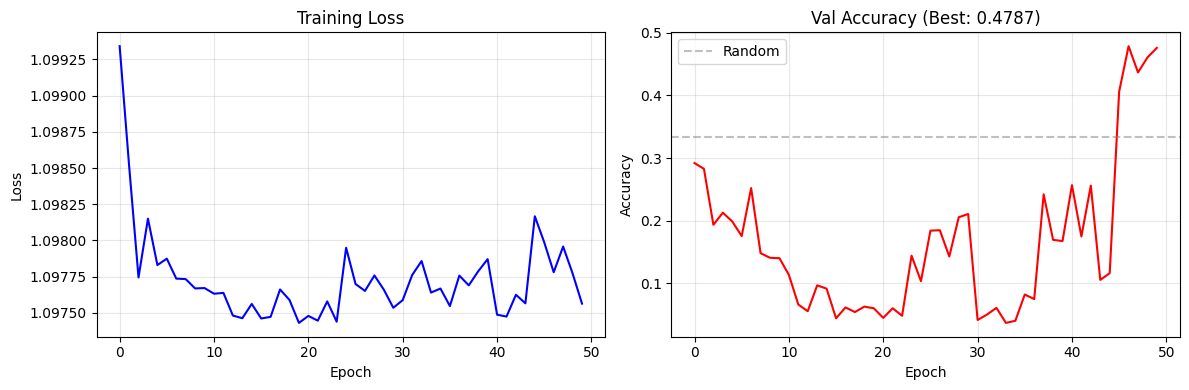

In [7]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], 'b-'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(alpha=0.3)
ax2.plot(history['val_acc'], 'r-'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Val Accuracy (Best: {best_val_acc:.4f})')
ax2.axhline(y=1/3, color='gray', ls='--', alpha=0.5, label='Random'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Evaluating best model on full val set...


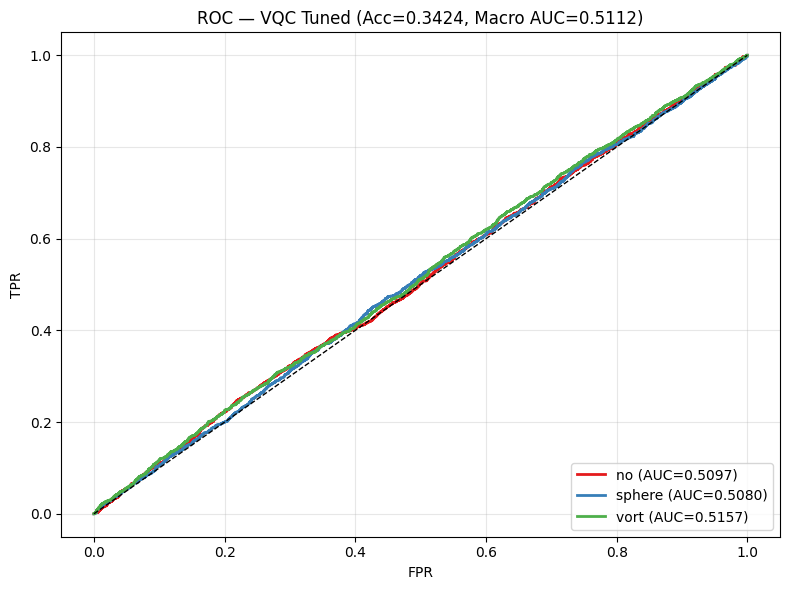

  no AUC: 0.5097
  sphere AUC: 0.5080
  vort AUC: 0.5157
Macro AUC: 0.5112


In [8]:
# Final evaluation
print('Evaluating best model on full val set...')
final_acc, all_probs, all_labels = evaluate(best_params, X_vl, y_vl)
all_labels_bin = label_binarize(all_labels, classes=[0,1,2])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for i, cn in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(all_labels_bin[:,i], all_probs[:,i])
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cn} (AUC={auc(fpr,tpr):.4f})')
macro_auc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovr', average='macro')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC — VQC Tuned (Acc={final_acc:.4f}, Macro AUC={macro_auc:.4f})')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_vqc_tuned.png', dpi=150); plt.show()

for i, cn in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(all_labels_bin[:,i], all_probs[:,i])
    print(f'  {cn} AUC: {auc(fpr,tpr):.4f}')
print(f'Macro AUC: {macro_auc:.4f}')